# Step 1 — Install Dependencies

In [1]:
!pip install -q transformers datasets scikit-learn pandas torch accelerate

# Step 2 — Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline
)
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from collections import Counter

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU device      : Tesla T4


#Step 3 — Load Dataset

In [3]:
from datasets import load_dataset

ticket_data = load_dataset("Tobi-Bueck/customer-support-tickets")
print(ticket_data)

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})


In [4]:
# Inspect the first few rows and column names
split_name = list(ticket_data.keys())[0]
initial_df = ticket_data[split_name].to_pandas()

print(f"Data split utilized : '{split_name}'")
print(f"DataFrame dimensions: {initial_df.shape}")
print(f"Available columns   : {initial_df.columns.tolist()}")
print("\nFirst 5 entries:")
display(initial_df.head(5))

Data split utilized : 'train'
DataFrame dimensions: (61765, 16)
Available columns   : ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

First 5 entries:


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


# Step 4 — Explore & Map Labels

In [5]:
# ── Identify text and label columns ──────────────────────────────────────────
# Adjust these names if the dataset columns differ after you print them above
text_feature_col  = 'subject'    # primary text column
category_col = 'queue'      # raw category column

# Fallback: use first object columns if the above names are not present
str_cols = initial_df.select_dtypes(include='object').columns.tolist()
if text_feature_col not in initial_df.columns:
    text_feature_col = str_cols[0]
if category_col not in initial_df.columns:
    category_col = str_cols[1] if len(str_cols) > 1 else str_cols[0]

print(f"Text content column   : {text_feature_col}")
print(f"Categorical label column: {category_col}")
print("\nInitial label distribution:")
print(initial_df[category_col].value_counts())

Text content column   : subject
Categorical label column: queue

Initial label distribution:
queue
Technical Support                         14186
Product Support                            8960
Customer Service                           7420
IT Support                                 5725
Billing and Payments                       4874
Returns and Exchanges                      2438
Service Outages and Maintenance            1912
Sales and Pre-Sales                        1490
Human Resources                             914
General Inquiry                             668
Pets & Animals/Pet Services                 386
News                                        383
IT & Technology/Security Operations         365
Autos & Vehicles/Sales                      364
Health/Medical Services                     362
Home & Garden/Home Improvement              361
Pets & Animals/Veterinary Care              356
Health/Mental Health                        347
Business & Industrial/Manufacturing  

In [6]:
# ── Map raw labels → 4 target categories ─────────────────────────────────────
def assign_ticket_category(raw_category: str) -> str:
    if pd.isna(raw_category):
        return 'Other'
    clean_raw = str(raw_category).lower()
    if any(k in clean_raw for k in ['delivery', 'shipping', 'package', 'damaged',
                             'shipment', 'courier', 'dispatch', 'lost',
                             'delay', 'transit', 'order']):
        return 'Delivery'
    if any(k in clean_raw for k in ['billing', 'payment', 'refund', 'invoice',
                             'charge', 'subscription', 'finance', 'bill']):
        return 'Billing'
    if any(k in clean_raw for k in ['technical', 'tech', 'login', 'password', 'error',
                             'bug', 'crash', 'access', 'account', 'software',
                             'app', 'website', 'server', 'api']):
        return 'Technical'
    return 'Other'

initial_df['mapped_category'] = initial_df[category_col].apply(assign_ticket_category)

print("Mapped category distribution:")
print(initial_df['mapped_category'].value_counts())

Mapped category distribution:
mapped_category
Other        40588
Technical    15664
Billing       5513
Name: count, dtype: int64


#Step 5 — Undersampling to Balance Classes

In [7]:
# Drop rows with empty text
processed_df = initial_df[[text_feature_col, 'mapped_category']].dropna(subset=[text_feature_col])
processed_df = processed_df[processed_df[text_feature_col].str.strip() != '']
processed_df.rename(columns={text_feature_col: 'text_content', 'mapped_category': 'target_label'}, inplace=True)

# ── Undersample: keep at most max_samples_per_category samples per class ─────
category_counts    = processed_df['target_label'].value_counts()
min_category_count = int(category_counts.min())
max_samples_per_category  = min(min_category_count, 1500)   # cap at 1500 per class for training speed

print(f"Number of samples per category after undersampling: {max_samples_per_category}")

sampled_subsets = []
for lbl in processed_df['target_label'].unique():
    subset  = processed_df[processed_df['target_label'] == lbl]
    sampled = resample(subset, replace=False,
                       n_samples=min(max_samples_per_category, len(subset)),
                       random_state=42)
    sampled_subsets.append(sampled)

final_balanced_df = pd.concat(sampled_subsets).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced target label distribution:")
print(final_balanced_df['target_label'].value_counts())
print(f"\nTotal balanced samples: {len(final_balanced_df)}")

Number of samples per category after undersampling: 1500

Balanced target label distribution:
target_label
Other        1500
Billing      1500
Technical    1500
Name: count, dtype: int64

Total balanced samples: 4500


#Step 6 — Encode Labels & Train / Val / Test Split

In [8]:
unique_categories = sorted(final_balanced_df['target_label'].unique().tolist())
category_to_id   = {l: i for i, l in enumerate(unique_categories)}
id_to_category   = {i: l for l, i in category_to_id.items()}
num_categories = len(unique_categories)

final_balanced_df['category_id'] = final_balanced_df['target_label'].map(category_to_id)

print(f"Mapped Categories ({num_categories}): {category_to_id}")

# 80 / 10 / 10 split  (stratified)
train_set_df, temp_df = train_test_split(final_balanced_df, test_size=0.20,
                                     stratify=final_balanced_df['category_id'],
                                     random_state=42)
validation_set_df, test_set_df   = train_test_split(temp_df,     test_size=0.50,
                                     stratify=temp_df['category_id'],
                                     random_state=42)

print(f"\nDataset Sizes: Training: {len(train_set_df)} | Validation: {len(validation_set_df)} | Test: {len(test_set_df)}")

Mapped Categories (3): {'Billing': 0, 'Other': 1, 'Technical': 2}

Dataset Sizes: Training: 3600 | Validation: 450 | Test: 450


# Step 7 — Tokeniser & HF Datasets

In [9]:
from transformers import AutoTokenizer

pretrained_model_identifier = "distilbert-base-uncased"   # 66 M params — fastest on Colab T4

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_identifier)
print(f"Tokenizer loaded from: {pretrained_model_identifier}")

Tokenizer loaded from: distilbert-base-uncased


In [10]:
import pandas as pd
from datasets import Dataset, DatasetDict

def convert_df_to_hf_dataset(dataframe: pd.DataFrame) -> Dataset:
    return Dataset.from_dict({
        'text' : dataframe['text_content'].tolist(),
        'label': dataframe['category_id'].tolist()
    })

hf_raw_datasets = DatasetDict({
    'train': convert_df_to_hf_dataset(train_set_df),
    'val'  : convert_df_to_hf_dataset(validation_set_df),
    'test' : convert_df_to_hf_dataset(test_set_df)
})
print(hf_raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3600
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 450
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 450
    })
})


In [11]:
def apply_tokenizer_to_batch(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128    # support tickets are typically concise
    )

tokenized_hf_datasets = hf_raw_datasets.map(apply_tokenizer_to_batch, batched=True,
                              remove_columns=['text'])
tokenized_hf_datasets.set_format('torch')
print(tokenized_hf_datasets)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3600
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 450
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 450
    })
})


#Step 8 — Load Pre-trained Model

In [12]:
from transformers import AutoModelForSequenceClassification

sequence_classifier_model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_identifier,
    num_labels=num_categories,
    id2label=id_to_category,
    label2id=category_to_id
)

total_parameters_count = sum(p.numel() for p in sequence_classifier_model.parameters())
trainable_parameters_count    = sum(p.numel() for p in sequence_classifier_model.parameters() if p.requires_grad)
print(f"Total model parameters    : {total_parameters_count:,}")
print(f"Trainable model parameters: {trainable_parameters_count:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total model parameters    : 66,955,779
Trainable model parameters: 66,955,779


#Step 9 — Fine-Tune with HF Trainer

In [13]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

def evaluate_performance_metrics(eval_pred):
    predictions_logits, true_labels = eval_pred
    predicted_ids = np.argmax(predictions_logits, axis=-1)
    return {'accuracy': accuracy_score(true_labels, predicted_ids)}


hf_data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model_training_arguments = TrainingArguments(
    output_dir                  = './ticket_classifier_output',
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'accuracy',
    logging_dir                 = './training_logs',
    logging_steps               = 50,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),  # Enable AMP on GPU if available
    dataloader_num_workers      = 2,
)

hf_trainer_instance = Trainer(
    model           = sequence_classifier_model,
    args            = model_training_arguments,
    train_dataset   = tokenized_hf_datasets['train'],
    eval_dataset    = tokenized_hf_datasets['val'],
    data_collator   = hf_data_collator,
    compute_metrics = evaluate_performance_metrics,
)

print("Initiating model training …")
training_outcome = hf_trainer_instance.train()
print("\nTraining process completed!")
print(training_outcome.metrics)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Initiating model training …


Epoch,Training Loss,Validation Loss,Accuracy
1,1.059073,0.918430,0.528889
2,0.855212,0.802577,0.580000
3,0.758974,0.812611,0.591111
4,0.666397,0.780351,0.608889
5,0.588323,0.790919,0.606667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training process completed!
{'train_runtime': 79.1547, 'train_samples_per_second': 227.403, 'train_steps_per_second': 7.138, 'total_flos': 150676073804736.0, 'train_loss': 0.789556569124745, 'epoch': 5.0}


#Step 10 — Evaluate on Test Set

In [14]:
evaluation_results_on_test = hf_trainer_instance.evaluate(eval_dataset=tokenized_hf_datasets['test'])

print("\nEvaluation Results on Test Set:")
for k, v in evaluation_results_on_test.items():
    print(f"  {k:30s}: {v:.4f}" if isinstance(v, float) else f"  {k:30s}: {v}")


Evaluation Results on Test Set:
  eval_loss                     : 0.7675
  eval_accuracy                 : 0.6333
  eval_runtime                  : 0.4504
  eval_samples_per_second       : 999.0930
  eval_steps_per_second         : 17.7620
  epoch                         : 5.0000


In [15]:
test_set_predictions = hf_trainer_instance.predict(tokenized_hf_datasets['test'])
predicted_labels = np.argmax(test_set_predictions.predictions, axis=-1)
actual_labels = test_set_predictions.label_ids

print("\nDetailed Classification Report:")
print(classification_report(actual_labels, predicted_labels, target_names=unique_categories))

overall_accuracy = accuracy_score(actual_labels, predicted_labels)
print(f"\nOverall Test Accuracy: {overall_accuracy:.4f}  ({overall_accuracy*100:.2f}%)")


Detailed Classification Report:
              precision    recall  f1-score   support

     Billing       0.82      0.72      0.77       150
       Other       0.54      0.53      0.54       150
   Technical       0.57      0.65      0.60       150

    accuracy                           0.63       450
   macro avg       0.64      0.63      0.64       450
weighted avg       0.64      0.63      0.64       450


Overall Test Accuracy: 0.6333  (63.33%)


# Step 11 — Confusion Matrix Heatmap

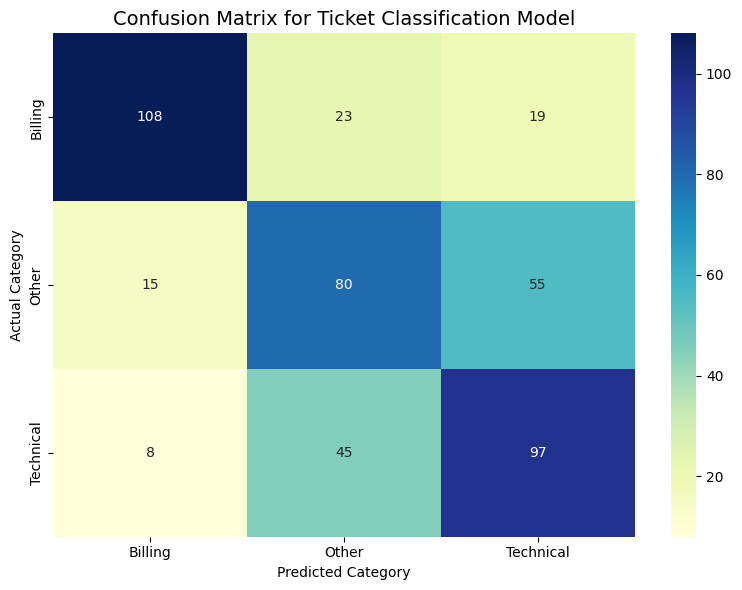

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

confusion_matrix_data = confusion_matrix(actual_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=unique_categories, yticklabels=unique_categories)
plt.title('Confusion Matrix for Ticket Classification Model', fontsize=14)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.show()

# Step 12 — Inference on New Tickets

In [17]:
import torch
from transformers import pipeline

device_for_inference = 0 if torch.cuda.is_available() else -1

inference_pipeline = pipeline(
    task      = 'text-classification',
    model     = sequence_classifier_model,
    tokenizer = tokenizer,
    device    = device_for_inference
)

sample_tickets_for_prediction = [
    "My credit card was charged multiple times",
    "I am unable to log into my online account",
    "My recent order arrived with a damaged item",
    "Still waiting for my refund after a week",
    "The package tracking shows no updates for days",
    "Application crashes every time I open it",
    "Received an incorrect bill for my services",
    "Where is my parcel?",
    "Password reset link expired before I could use it",
    "The amount on my invoice is wrong"
]

print(f"{'Customer Ticket Query':<50} {'Assigned Category':<18} {'Confidence Score':>15}")
print("-" * 83)

prediction_outputs = inference_pipeline(sample_tickets_for_prediction)
for ticket_text, prediction_result in zip(sample_tickets_for_prediction, prediction_outputs):
    print(f"{ticket_text:<50} {prediction_result['label']:<18} {prediction_result['score']:>15.2%}")

Customer Ticket Query                              Assigned Category  Confidence Score
-----------------------------------------------------------------------------------
My credit card was charged multiple times          Billing                     94.18%
I am unable to log into my online account          Other                       45.44%
My recent order arrived with a damaged item        Other                       43.74%
Still waiting for my refund after a week           Billing                     94.18%
The package tracking shows no updates for days     Other                       53.62%
Application crashes every time I open it           Technical                   72.06%
Received an incorrect bill for my services         Billing                     91.73%
Where is my parcel?                                Billing                     64.58%
Password reset link expired before I could use it  Technical                   43.49%
The amount on my invoice is wrong                  Bill

# Step 13 — Save the Model

In [18]:
model_save_directory = 'customer_support_classifier_v2'

sequence_classifier_model.save_pretrained(model_save_directory)
tokenizer.save_pretrained(model_save_directory)

print(f"Classification model saved to: '{model_save_directory}'")
print("   To reload this model, use:")
print(f"   AutoModelForSequenceClassification.from_pretrained('{model_save_directory}')")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Classification model saved to: 'customer_support_classifier_v2'
   To reload this model, use:
   AutoModelForSequenceClassification.from_pretrained('customer_support_classifier_v2')


# Step 14 — (Optional) Reload Saved Model & Predict

In [19]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

reloaded_model     = AutoModelForSequenceClassification.from_pretrained(model_save_directory)
reloaded_tokenizer = AutoTokenizer.from_pretrained(model_save_directory)

reloaded_pipeline = pipeline('text-classification',
                model=reloaded_model,
                tokenizer=reloaded_tokenizer,
                device=device_for_inference)

single_ticket_text = "My package has not been delivered and it's been over two weeks now"
single_prediction_result    = reloaded_pipeline(single_ticket_text)[0]
print(f"Sample Ticket Text : {single_ticket_text}")
print(f"Predicted Category : {single_prediction_result['label']}  (Confidence: {single_prediction_result['score']:.2%})")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sample Ticket Text : My package has not been delivered and it's been over two weeks now
Predicted Category : Other  (Confidence: 39.93%)
